In [11]:
import pandas as pd

# Load CSV file
df = pd.read_csv('Salivary transmition dataset.csv')

# Remove leading/trailing spaces in column names
df.columns = df.columns.str.strip()

# Show first 5 rows of dataset
print(df.head())

# Show all column names to confirm exact spelling/punctuation
print(df.columns.tolist())

   Gender:  Age:  Level of education:  Age of residence:  \
0        2     1                    3                  1   
1        2     2                    4                  1   
2        1     4                    4                  1   
3        1     4                    3                  1   
4        2     2                    3                  1   

   Province of residence:\n:  Have you ever visited a dentist?  \
0                          1                                 0   
1                          1                                 1   
2                          1                                 1   
3                          1                                 1   
4                          1                                 1   

   How often do you brush your teeth?  \
0                                   2   
1                                   2   
2                                   1   
3                                   1   
4                                   1

In [12]:
# Exact feature columns from your dataset (copy paste directly from df.columns)
feature_columns = [
    'Gender:', 'Level of education:', 'Age of residence:', 'Province of residence:\n:',
    'Have you ever visited a dentist?', 'How often do you brush your teeth?',
    'What do you believe are the main causes of tooth decay?', 'Have you heard the term ?dental caries??',
    'Do you think dental caries can spread from one person to a0ther?', 'Do you believe bacteria can be transmitted through saliva?',
    'Which of the following behaviors do you think can transmit saliva? (Select all that apply)',
    'Do you think any of the above behaviors can increase the risk of oral health issues?', 'Are you aware that harmful bacteria related to tooth decay can be passed from one person to a0ther?',
    'Have you ever received information from a health professional or media about the contagious nature of oral diseases?', 'Do you commonly share your utensils, straws, or cups with 5s?',
    'Have you ever fed a child using your mouth or the same spoon?', 'Do you and your any family member use the same toothbrush or oral hygiene tools?',
    'If you were informed that oral bacteria could be spread through saliva, would it change your hygiene habits?', 'Which of the following statements do you agree with? (Select all that apply)',
    'What would be your preferred way to learn about preventing salivary transmission of bacteria?'
]

target_column = 'Age:'

# Select features and target
X = df[feature_columns]
y = df[target_column]

print("Features preview:")
print(X.head())

print("Target preview:")
print(y.head())


Features preview:
   Gender:  Level of education:  Age of residence:  Province of residence:\n:  \
0        2                    3                  1                          1   
1        2                    4                  1                          1   
2        1                    4                  1                          1   
3        1                    3                  1                          1   
4        2                    3                  1                          1   

   Have you ever visited a dentist?  How often do you brush your teeth?  \
0                                 0                                   2   
1                                 1                                   2   
2                                 1                                   1   
3                                 1                                   1   
4                                 1                                   1   

  What do you believe are the main causes of

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify categorical and numeric columns in features
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

# Create ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ],
    remainder='drop'  # Drop any other columns if present
)

# Fit and transform the features
X_processed = preprocessor.fit_transform(X)

print("Preprocessing done. Processed feature shape:", X_processed.shape)


Categorical columns: ['What do you believe are the main causes of tooth decay?', 'Which of the following behaviors do you think can transmit saliva? (Select all that apply)', 'Which of the following statements do you agree with? (Select all that apply)', 'What would be your preferred way to learn about preventing salivary transmission of bacteria?']
Numeric columns: ['Gender:', 'Level of education:', 'Age of residence:', 'Province of residence:\n:', 'Have you ever visited a dentist?', 'How often do you brush your teeth?', 'Have you heard the term ?dental caries??', 'Do you think dental caries can spread from one person to a0ther?', 'Do you believe bacteria can be transmitted through saliva?', 'Do you think any of the above behaviors can increase the risk of oral health issues?', 'Are you aware that harmful bacteria related to tooth decay can be passed from one person to a0ther?', 'Have you ever received information from a health professional or media about the contagious nature of oral

In [14]:
# Convert categorical target variable 'Age:' to numeric codes (0, 1, 2, ...)
y = df['Age:'].astype('category').cat.codes

# Now y is numeric class labels suitable for classification tasks
print(y.head())
print("Unique classes:", y.unique())

0    0
1    1
2    3
3    3
4    1
dtype: int8
Unique classes: [0 1 3 2]


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Assuming X_processed and y are preprocessed features and numeric class labels

# Use stratified split to maintain class distribution balance
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "MLP Classifier": MLPClassifier(max_iter=300),
    "Support Vector Machine": SVC(kernel='rbf', gamma='scale')
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

    # Use zero_division=0 to avoid warnings when no positive predictions for a class
    print(classification_report(y_test, y_pred, zero_division=0))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("="*40)


Model: Logistic Regression
Accuracy: 0.790
              precision    recall  f1-score   support

           0       0.25      0.25      0.25         4
           1       0.86      0.94      0.90        51
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         4

    accuracy                           0.79        62
   macro avg       0.28      0.30      0.29        62
weighted avg       0.72      0.79      0.75        62

Confusion Matrix:
[[ 1  3  0  0]
 [ 1 48  1  1]
 [ 1  2  0  0]
 [ 1  3  0  0]]
Model: Random Forest
Accuracy: 0.823
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.82      1.00      0.90        51
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         4

    accuracy                           0.82        62
   macro avg       0.21      0.25      0.23        62
weighted avg       0.68   

/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Model: MLP Classifier
Accuracy: 0.839
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         4
           1       0.88      0.98      0.93        51
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         4

    accuracy                           0.84        62
   macro avg       0.34      0.37      0.36        62
weighted avg       0.75      0.84      0.79        62

Confusion Matrix:
[[ 2  2  0  0]
 [ 0 50  1  0]
 [ 1  2  0  0]
 [ 1  3  0  0]]
Model: Support Vector Machine
Accuracy: 0.823
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.82      1.00      0.90        51
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         4

    accuracy                           0.82        62
   macro avg       0.21      0.25      0.23        62
weighted avg       0.6

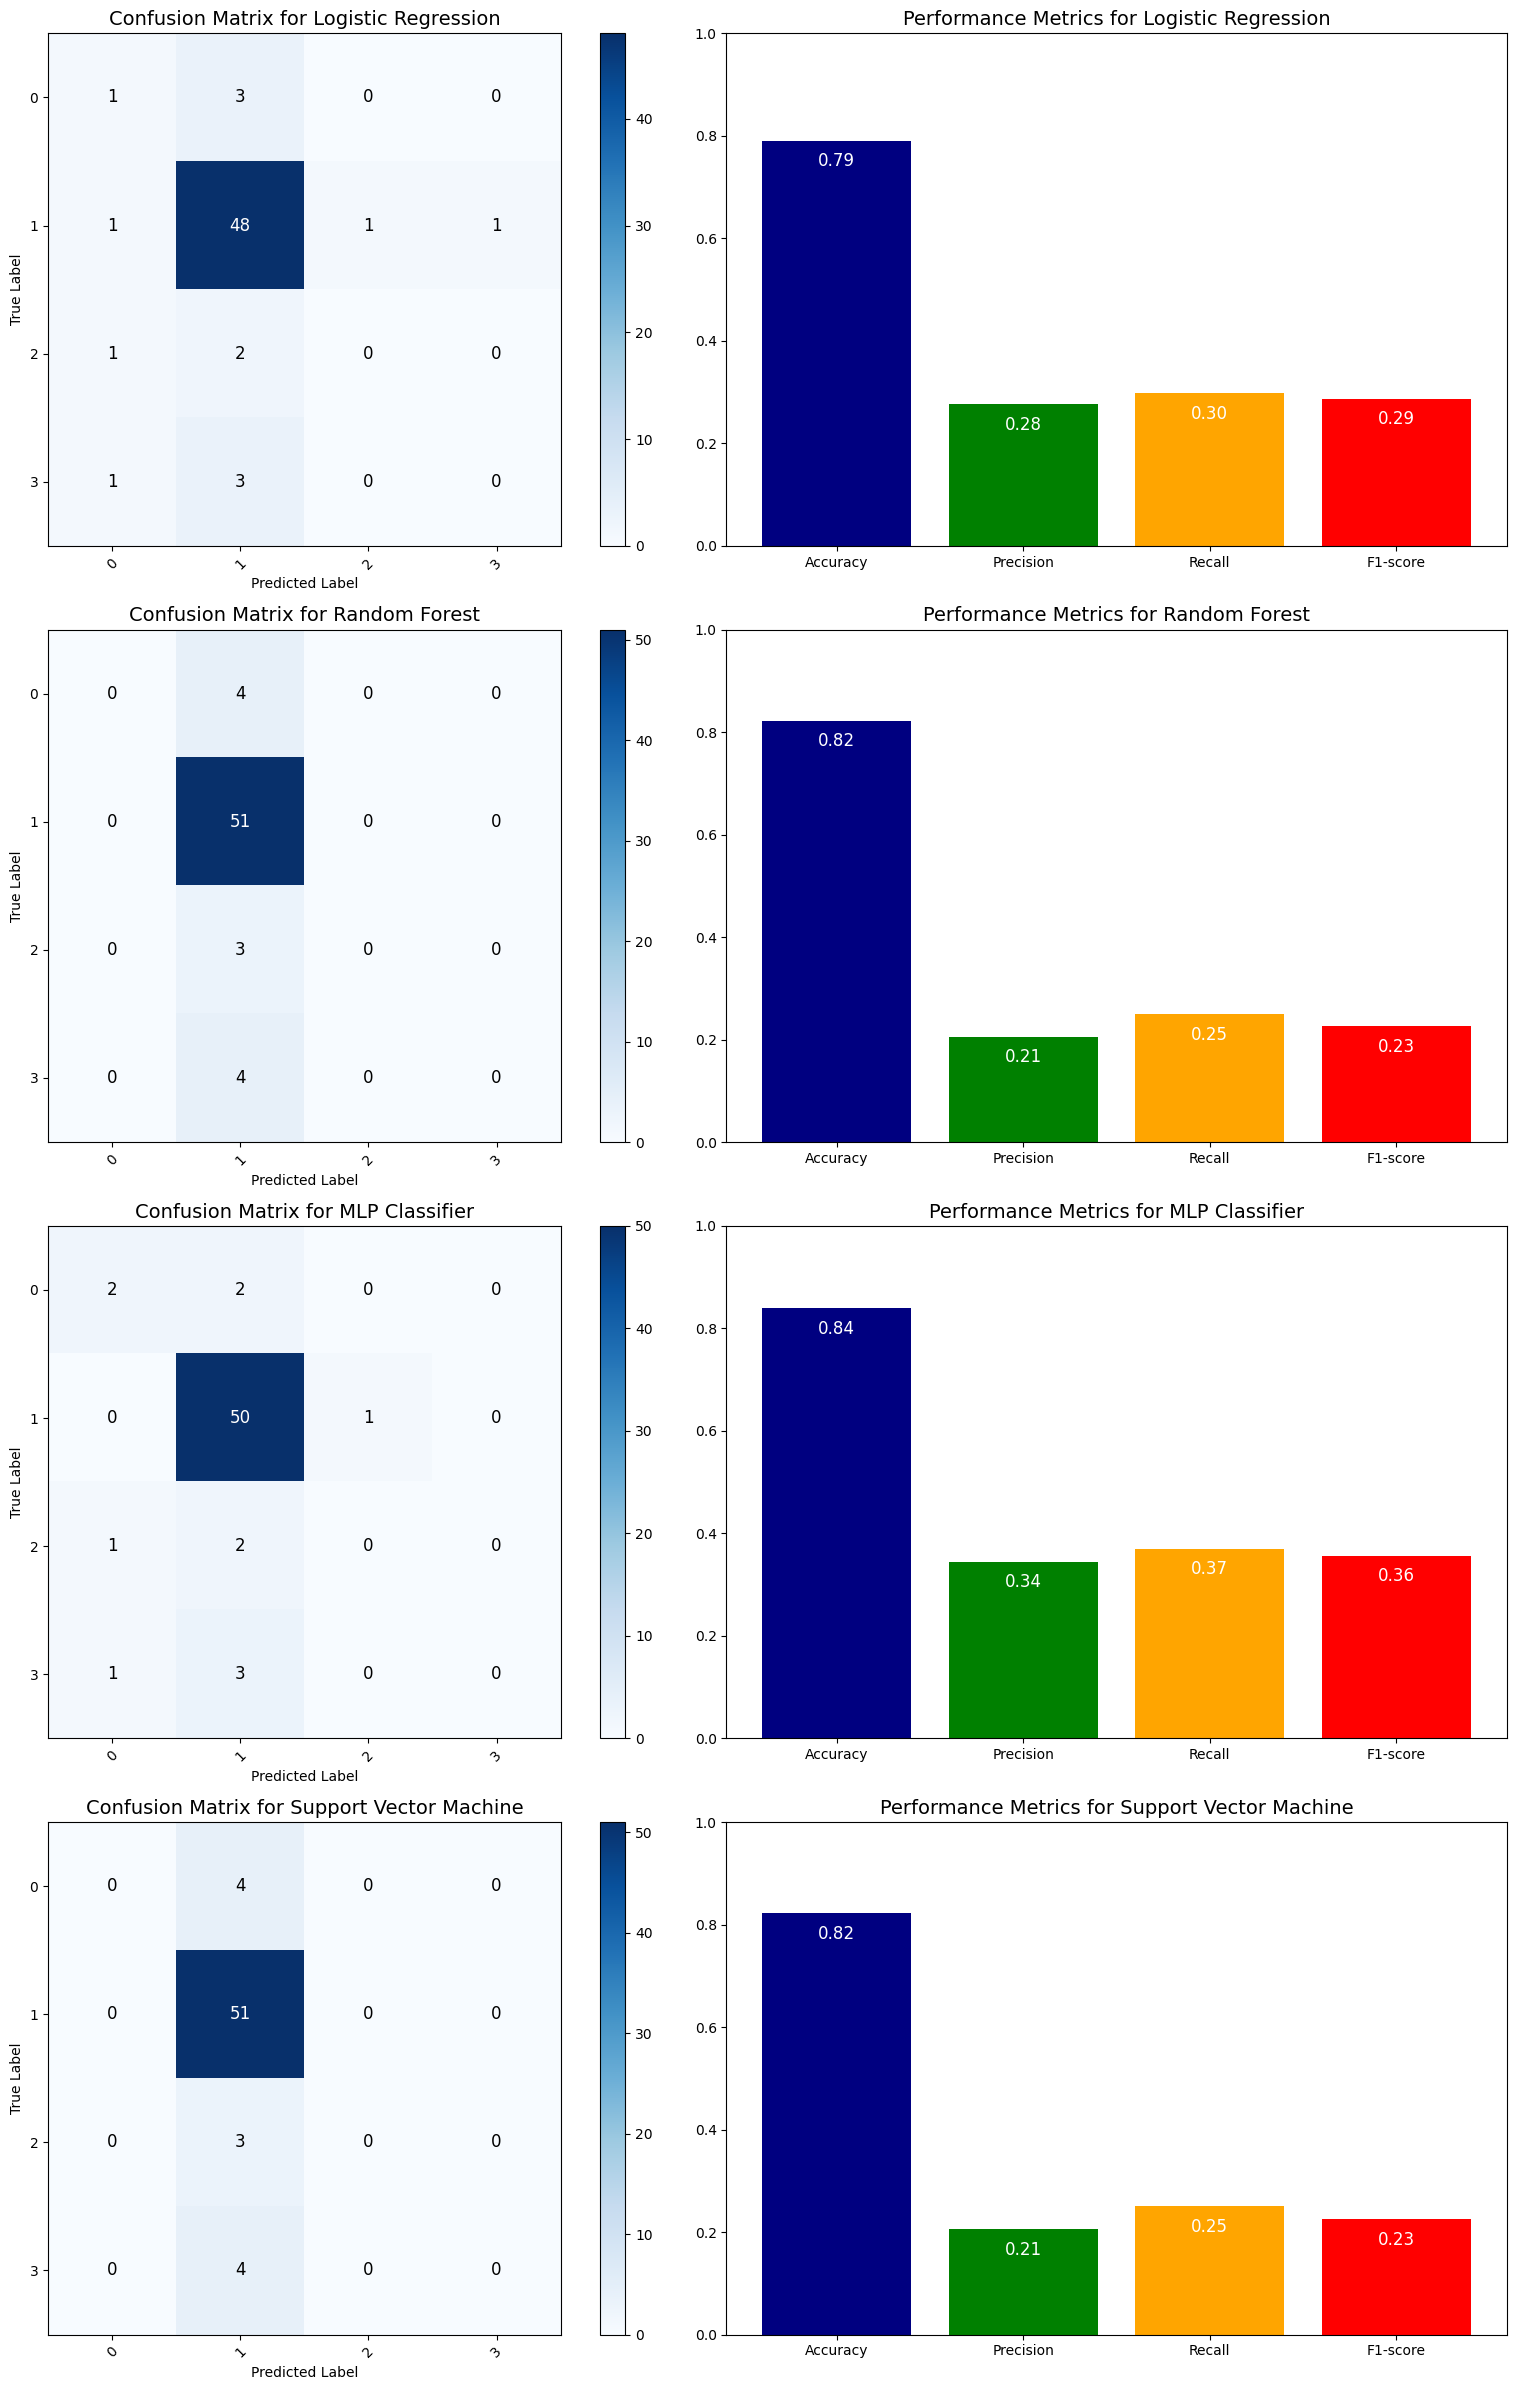

In [16]:
import matplotlib.pyplot as plt
import numpy as np

model_names = []
accuracies = []
precisions = []
recalls = []
f1_scores = []

plt.figure(figsize=(16, 24))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    
    # Calculate macro averaged precision, recall, f1-score
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    f1 = report['macro avg']['f1-score']
    
    model_names.append(name)
    accuracies.append(acc)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    
    # Plot confusion matrix heatmap using matplotlib only
    
    cm = confusion_matrix(y_test, y_pred)
    plt.subplot(len(models), 2, 2*i + 1)
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {name}', fontsize=14)
    plt.colorbar()
    tick_marks = np.arange(len(np.unique(y_test)))
    plt.xticks(tick_marks, np.unique(y_test), rotation=45)
    plt.yticks(tick_marks, np.unique(y_test))
    
    thresh = cm.max() / 2.
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            plt.text(col, row, format(cm[row, col], 'd'),
                     ha="center", va="center",
                     color="white" if cm[row, col] > thresh else "black",
                     fontsize=12)
    
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    # Plot bar chart of metrics for the model
    plt.subplot(len(models), 2, 2*i + 2)
    metrics = [acc, precision, recall, f1]
    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']
    bars = plt.bar(metric_names, metrics, color=['navy', 'green', 'orange', 'red'])
    plt.title(f'Performance Metrics for {name}', fontsize=14)
    plt.ylim(0, 1)
    
    for bar, metric in zip(bars, metrics):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.05,
                 f"{metric:.2f}", ha="center", color="white", fontsize=12)

plt.tight_layout()
plt.show()


Model: Logistic Regression
Accuracy: 0.790
Sensitivity (Recall): 0.298
Specificity: 0.797
------------------------------
Model: Random Forest
Accuracy: 0.823
Sensitivity (Recall): 0.250
Specificity: 0.750
------------------------------
Model: MLP Classifier
Accuracy: 0.839
Sensitivity (Recall): 0.370
Specificity: 0.828
------------------------------
Model: Support Vector Machine
Accuracy: 0.823
Sensitivity (Recall): 0.250
Specificity: 0.750
------------------------------


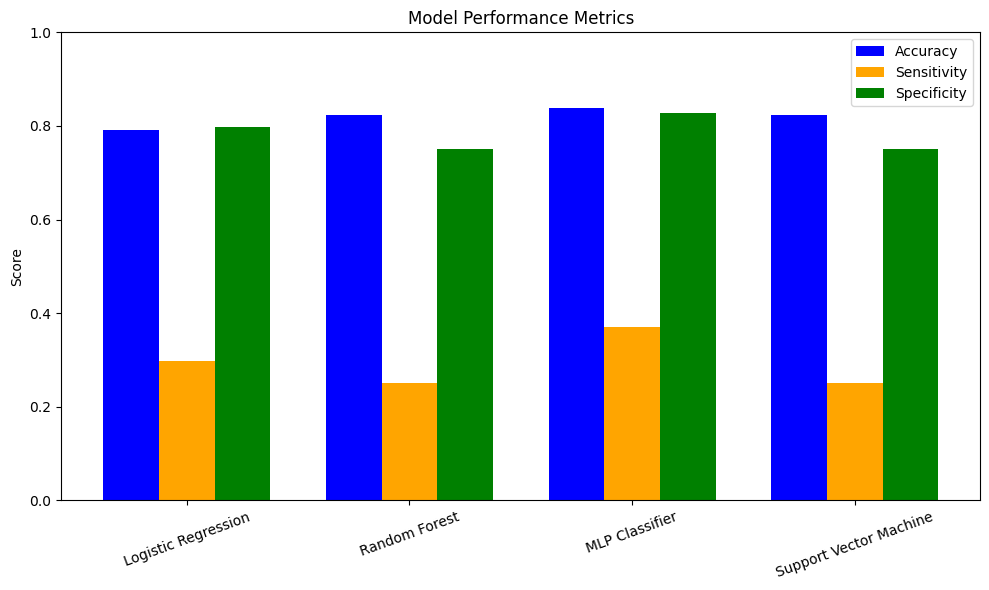

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score

def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    # For binary classification, specificity = TN / (TN + FP)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp)
    else:
        # For multi-class, compute specificity per class and average
        specificity_per_class = []
        for i in range(cm.shape[0]):
            tp_i = cm[i, i]
            fp_i = cm[:, i].sum() - tp_i
            fn_i = cm[i, :].sum() - tp_i
            tn_i = cm.sum() - (tp_i + fp_i + fn_i)
            specificity_per_class.append(tn_i / (tn_i + fp_i))
        return np.mean(specificity_per_class)

model_names = []
accuracies = []
sensitivities = []
specificities = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    sens = recall_score(y_test, y_pred, average='macro', zero_division=0)  # Sensitivity = Recall
    spec = specificity_score(y_test, y_pred)
    
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.3f}")
    print(f"Sensitivity (Recall): {sens:.3f}")
    print(f"Specificity: {spec:.3f}")
    print("-" * 30)

    model_names.append(name)
    accuracies.append(acc)
    sensitivities.append(sens)
    specificities.append(spec)

# Plotting the results for visual comparison
plt.figure(figsize=(10, 6))
x = np.arange(len(model_names))
width = 0.25

plt.bar(x - width, accuracies, width, label='Accuracy', color='blue')
plt.bar(x, sensitivities, width, label='Sensitivity', color='orange')
plt.bar(x + width, specificities, width, label='Specificity', color='green')

plt.xticks(x, model_names, rotation=20)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Model Performance Metrics')
plt.legend()
plt.tight_layout()
plt.show()
